# Benchmark NER spaCy × Presidio — Performance par taille de modèle

Ce notebook mesure l'impact du **choix du modèle NER spaCy** sur :
- la **qualité de détection** (précision, rappel, F1) pour les entités PERSON, LOCATION, DATE_TIME
- la **vitesse d'inférence** (ms/texte, textes/sec)
- l'**empreinte mémoire** (taille du modèle chargé)

L'objectif est de guider le choix de `PII_MASKING_NER_MODEL_EN` / `PII_MASKING_NER_MODEL_FR` dans RAGFlow.

---

## Modèles testés

| Modèle | Langue | Architecture | Taille approx. |
|--------|--------|-------------|----------------|
| `en_core_web_sm` | EN | tok2vec (CNN) | ~12 MB |
| `en_core_web_md` | EN | tok2vec + vecteurs 20k | ~43 MB |
| `en_core_web_lg` | EN | tok2vec + vecteurs 685k | ~560 MB |
| `en_core_web_trf` | EN | RoBERTa (transformer) | ~440 MB |
| `fr_core_news_sm` | FR | tok2vec (CNN) | ~15 MB |
| `fr_core_news_md` | FR | tok2vec + vecteurs | ~46 MB |
| `fr_core_news_lg` | FR | tok2vec + vecteurs 500k | ~570 MB |

---

## Sommaire

1. [Installation & configuration](#1-install)
2. [Dataset de référence annoté](#2-dataset)
3. [Fonctions de benchmark](#3-benchmark)
4. [Benchmark anglais](#4-en)
5. [Benchmark français](#5-fr)
6. [Analyse qualité : précision / rappel / F1](#6-quality)
7. [Analyse vitesse : latence & débit](#7-speed)
8. [Analyse mémoire](#8-memory)
9. [Synthèse & recommandations](#9-summary)

---
## 1. Installation & configuration <a id="1-install"></a>

In [6]:
# Installer les dépendances de base (à exécuter une seule fois par environnement)
%pip install -q presidio-analyzer presidio-anonymizer spacy

# Anglais
!python -m spacy download en_core_web_sm
!python -m spacy download en_core_web_md
!python -m spacy download en_core_web_lg
%pip install -q "spacy[transformers]"
!python -m spacy download en_core_web_trf

# Français
!python -m spacy download fr_core_news_sm
!python -m spacy download fr_core_news_md
!python -m spacy download fr_core_news_lg

Note: you may need to restart the kernel to use updated packages.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 13.5 MB/s eta 0:00:00a 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 10.6 MB/s eta 0:00:00a 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 6.0 MB/s eta 0:00:0000:0100:02
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
Note: you may need to restart the kernel to use updated packages.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 457.4/457.4 MB 5.1 MB/s eta 0:00:0000:0100:03
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 703.3/703.3 kB 18.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_trf')
     ━━━━━━━━━━━━━━━

In [7]:
import gc
import sys
import time
import tracemalloc
import warnings
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple

import spacy
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from presidio_analyzer import AnalyzerEngine, RecognizerResult
from presidio_analyzer.nlp_engine import NlpEngineProvider

warnings.filterwarnings("ignore")

# Reproductibilité
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Style graphiques
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

print(f"Python {sys.version.split()[0]} | spaCy {spacy.__version__}")
print("✅ Imports OK")

Python 3.11.3 | spaCy 3.8.14
✅ Imports OK


In [8]:
# ── Modèles à tester ──
# Retirez les modèles non installés de ces listes.

EN_MODELS = [
    "en_core_web_sm",
    "en_core_web_md",
    # "en_core_web_lg",   # ~560 MB — décommenter si disponible
    # "en_core_web_trf",  # ~440 MB + GPU recommandé
]

FR_MODELS = [
    "fr_core_news_sm",
    # "fr_core_news_md",  # décommenter si disponible
    # "fr_core_news_lg",
]

# Entités NER testées (celles que spaCy peut détecter)
NER_ENTITIES = ["PERSON", "LOCATION", "DATE_TIME"]

# Nombre de répétitions pour les mesures de temps (stabilité statistique)
N_WARMUP = 3      # passages ignorés (JIT / cache)
N_REPEAT = 20     # passages mesurés

print(f"Modèles EN : {EN_MODELS}")
print(f"Modèles FR : {FR_MODELS}")
print(f"Entités    : {NER_ENTITIES}")
print(f"Répétitions: {N_REPEAT} (+ {N_WARMUP} warmup)")

Modèles EN : ['en_core_web_sm', 'en_core_web_md']
Modèles FR : ['fr_core_news_sm']
Entités    : ['PERSON', 'LOCATION', 'DATE_TIME']
Répétitions: 20 (+ 3 warmup)


---
## 2. Dataset de référence annoté <a id="2-dataset"></a>

Chaque exemple est un texte avec les **entités attendues** (ground truth) :
- type d'entité
- valeur exacte telle qu'elle apparaît dans le texte

Le dataset couvre différentes difficultés :
- noms simples vs composés
- lieux ambigus ("Paris" peut être un prénom)
- dates littérales vs numériques
- contextes RAG réalistes (extraits de documents)

In [9]:
@dataclass
class GroundTruthEntity:
    entity_type: str
    value: str       # valeur exacte dans le texte


@dataclass
class Sample:
    text: str
    language: str
    expected: List[GroundTruthEntity]
    difficulty: str = "normal"   # easy / normal / hard
    category: str = "general"    # general / rag_context / ambiguous


# ──────────────────────────────────────────────────────────────────
# Dataset anglais
# ──────────────────────────────────────────────────────────────────
EN_DATASET = [
    # Facile — entités isolées, contexte clair
    Sample(
        text="My name is John Smith and I live in London.",
        language="en",
        expected=[GroundTruthEntity("PERSON", "John Smith"), GroundTruthEntity("LOCATION", "London")],
        difficulty="easy", category="general",
    ),
    Sample(
        text="Please contact Dr. Sarah Connor at our New York office.",
        language="en",
        expected=[GroundTruthEntity("PERSON", "Sarah Connor"), GroundTruthEntity("LOCATION", "New York")],
        difficulty="easy", category="general",
    ),
    Sample(
        text="The meeting with Alice Johnson is scheduled for January 15th.",
        language="en",
        expected=[GroundTruthEntity("PERSON", "Alice Johnson"), GroundTruthEntity("DATE_TIME", "January 15th")],
        difficulty="easy", category="general",
    ),

    # Normal — phrases plus longues, entités multiples
    Sample(
        text="Customer Bob Williams filed a complaint on March 3rd, 2024 from our Chicago branch.",
        language="en",
        expected=[
            GroundTruthEntity("PERSON", "Bob Williams"),
            GroundTruthEntity("DATE_TIME", "March 3rd, 2024"),
            GroundTruthEntity("LOCATION", "Chicago"),
        ],
        difficulty="normal", category="general",
    ),
    Sample(
        text="The contract between Emma Davis and the Paris office was signed on 2023-11-01.",
        language="en",
        expected=[
            GroundTruthEntity("PERSON", "Emma Davis"),
            GroundTruthEntity("LOCATION", "Paris"),
            GroundTruthEntity("DATE_TIME", "2023-11-01"),
        ],
        difficulty="normal", category="general",
    ),

    # Contexte RAG — extraits de documents professionnels
    Sample(
        text=(
            "Employee record: James Martin, hired on September 1st 2021, "
            "assigned to the Berlin office. Manager: Laura Chen."
        ),
        language="en",
        expected=[
            GroundTruthEntity("PERSON", "James Martin"),
            GroundTruthEntity("DATE_TIME", "September 1st 2021"),
            GroundTruthEntity("LOCATION", "Berlin"),
            GroundTruthEntity("PERSON", "Laura Chen"),
        ],
        difficulty="normal", category="rag_context",
    ),
    Sample(
        text=(
            "Meeting notes — 14 Feb 2024. Attendees: Mark Thompson (London), "
            "Yuki Tanaka (Tokyo HQ), Sophie Bernard (Paris). Action: follow-up by 28 Feb."
        ),
        language="en",
        expected=[
            GroundTruthEntity("DATE_TIME", "14 Feb 2024"),
            GroundTruthEntity("PERSON", "Mark Thompson"),
            GroundTruthEntity("LOCATION", "London"),
            GroundTruthEntity("PERSON", "Yuki Tanaka"),
            GroundTruthEntity("LOCATION", "Tokyo"),
            GroundTruthEntity("PERSON", "Sophie Bernard"),
            GroundTruthEntity("LOCATION", "Paris"),
            GroundTruthEntity("DATE_TIME", "28 Feb"),
        ],
        difficulty="normal", category="rag_context",
    ),

    # Difficile — ambiguïtés et noms peu courants
    Sample(
        text="Paris called to confirm the Lyon meeting on Tuesday.",
        language="en",
        expected=[
            GroundTruthEntity("LOCATION", "Paris"),
            GroundTruthEntity("LOCATION", "Lyon"),
            GroundTruthEntity("DATE_TIME", "Tuesday"),
        ],
        difficulty="hard", category="ambiguous",
    ),
    Sample(
        text="Wei Zhang and Priya Patel joined the Singapore team last Monday.",
        language="en",
        expected=[
            GroundTruthEntity("PERSON", "Wei Zhang"),
            GroundTruthEntity("PERSON", "Priya Patel"),
            GroundTruthEntity("LOCATION", "Singapore"),
            GroundTruthEntity("DATE_TIME", "last Monday"),
        ],
        difficulty="hard", category="general",
    ),
    Sample(
        text=(
            "As of Q3 2023, our APAC lead Hiroshi Nakamura reports "
            "strong growth across Seoul, Osaka and Jakarta."
        ),
        language="en",
        expected=[
            GroundTruthEntity("DATE_TIME", "Q3 2023"),
            GroundTruthEntity("PERSON", "Hiroshi Nakamura"),
            GroundTruthEntity("LOCATION", "Seoul"),
            GroundTruthEntity("LOCATION", "Osaka"),
            GroundTruthEntity("LOCATION", "Jakarta"),
        ],
        difficulty="hard", category="rag_context",
    ),
]

# ──────────────────────────────────────────────────────────────────
# Dataset français
# ──────────────────────────────────────────────────────────────────
FR_DATASET = [
    Sample(
        text="Je m'appelle Marie Dupont et j'habite à Bordeaux.",
        language="fr",
        expected=[GroundTruthEntity("PERSON", "Marie Dupont"), GroundTruthEntity("LOCATION", "Bordeaux")],
        difficulty="easy", category="general",
    ),
    Sample(
        text="Le directeur Antoine Bernard a signé le contrat le 12 janvier 2024 au bureau de Lyon.",
        language="fr",
        expected=[
            GroundTruthEntity("PERSON", "Antoine Bernard"),
            GroundTruthEntity("DATE_TIME", "12 janvier 2024"),
            GroundTruthEntity("LOCATION", "Lyon"),
        ],
        difficulty="normal", category="general",
    ),
    Sample(
        text=(
            "Dossier employée : Camille Moreau, recrutée le 3 mars 2022, "
            "affectée au site de Nantes. Responsable : Pierre Lefevre."
        ),
        language="fr",
        expected=[
            GroundTruthEntity("PERSON", "Camille Moreau"),
            GroundTruthEntity("DATE_TIME", "3 mars 2022"),
            GroundTruthEntity("LOCATION", "Nantes"),
            GroundTruthEntity("PERSON", "Pierre Lefevre"),
        ],
        difficulty="normal", category="rag_context",
    ),
    Sample(
        text=(
            "Réunion du 7 février 2024 — Participants : Fatima El Amrani (Casablanca), "
            "Julien Martin (Paris), Hoa Nguyen (Marseille). Prochaine réunion : 21 février."
        ),
        language="fr",
        expected=[
            GroundTruthEntity("DATE_TIME", "7 février 2024"),
            GroundTruthEntity("PERSON", "Fatima El Amrani"),
            GroundTruthEntity("LOCATION", "Casablanca"),
            GroundTruthEntity("PERSON", "Julien Martin"),
            GroundTruthEntity("LOCATION", "Paris"),
            GroundTruthEntity("PERSON", "Hoa Nguyen"),
            GroundTruthEntity("LOCATION", "Marseille"),
            GroundTruthEntity("DATE_TIME", "21 février"),
        ],
        difficulty="normal", category="rag_context",
    ),
    Sample(
        text="Paris a confirmé le rendez-vous de mardi avec l'équipe de Nice.",
        language="fr",
        expected=[
            GroundTruthEntity("LOCATION", "Paris"),
            GroundTruthEntity("DATE_TIME", "mardi"),
            GroundTruthEntity("LOCATION", "Nice"),
        ],
        difficulty="hard", category="ambiguous",
    ),
    Sample(
        text=(
            "Au T3 2023, notre responsable EMEA Abderrahim Benali "
            "note une forte croissance à Tunis, Dakar et Abidjan."
        ),
        language="fr",
        expected=[
            GroundTruthEntity("DATE_TIME", "T3 2023"),
            GroundTruthEntity("PERSON", "Abderrahim Benali"),
            GroundTruthEntity("LOCATION", "Tunis"),
            GroundTruthEntity("LOCATION", "Dakar"),
            GroundTruthEntity("LOCATION", "Abidjan"),
        ],
        difficulty="hard", category="rag_context",
    ),
]

total_en = sum(len(s.expected) for s in EN_DATASET)
total_fr = sum(len(s.expected) for s in FR_DATASET)
print(f"Dataset EN : {len(EN_DATASET)} textes, {total_en} entités attendues")
print(f"Dataset FR : {len(FR_DATASET)} textes, {total_fr} entités attendues")

# Distribution par difficulté
for lang, dataset in [("EN", EN_DATASET), ("FR", FR_DATASET)]:
    from collections import Counter
    diff = Counter(s.difficulty for s in dataset)
    cats = Counter(s.category for s in dataset)
    print(f"  {lang} — difficultés: {dict(diff)} | catégories: {dict(cats)}")

Dataset EN : 10 textes, 36 entités attendues
Dataset FR : 6 textes, 25 entités attendues
  EN — difficultés: {'easy': 3, 'normal': 4, 'hard': 3} | catégories: {'general': 6, 'rag_context': 3, 'ambiguous': 1}
  FR — difficultés: {'easy': 1, 'normal': 3, 'hard': 2} | catégories: {'general': 2, 'rag_context': 3, 'ambiguous': 1}


---
## 3. Fonctions de benchmark <a id="3-benchmark"></a>

In [10]:
@dataclass
class EntityMatch:
    """Résultat de la comparaison détection vs ground truth."""
    tp: int = 0   # True Positive  : détecté ET dans ground truth
    fp: int = 0   # False Positive : détecté MAIS pas dans ground truth
    fn: int = 0   # False Negative : dans ground truth MAIS non détecté

    @property
    def precision(self) -> float:
        return self.tp / (self.tp + self.fp) if (self.tp + self.fp) > 0 else 0.0

    @property
    def recall(self) -> float:
        return self.tp / (self.tp + self.fn) if (self.tp + self.fn) > 0 else 0.0

    @property
    def f1(self) -> float:
        p, r = self.precision, self.recall
        return 2 * p * r / (p + r) if (p + r) > 0 else 0.0


def _normalize(text: str) -> str:
    """Normalisation légère pour comparaison souple."""
    return " ".join(text.lower().split())


def evaluate_sample(
    predicted: List[RecognizerResult],
    ground_truth: List[GroundTruthEntity],
    text: str,
    entity_type: str,
    partial_match: bool = True,
) -> Tuple[int, int, int]:
    """
    Calcule TP, FP, FN pour une entité donnée sur un texte.

    Matching : la valeur prédite doit être contenue dans la valeur GT
    ou inversement (partial_match=True), sinon égalité stricte normalisée.
    """
    gt_values = [
        _normalize(e.value)
        for e in ground_truth
        if e.entity_type == entity_type
    ]
    pred_values = [
        _normalize(text[r.start:r.end])
        for r in predicted
        if r.entity_type == entity_type
    ]

    def matches(pred: str, gt: str) -> bool:
        if partial_match:
            return pred in gt or gt in pred
        return pred == gt

    matched_gt = set()
    tp = 0
    for pred in pred_values:
        for i, gt in enumerate(gt_values):
            if i not in matched_gt and matches(pred, gt):
                tp += 1
                matched_gt.add(i)
                break

    fp = len(pred_values) - tp
    fn = len(gt_values) - tp
    return tp, fp, fn


def build_analyzer(model_name: str, language: str) -> Optional[AnalyzerEngine]:
    """Construit un AnalyzerEngine Presidio avec le modèle spaCy donné."""
    try:
        nlp_config = {
            "nlp_engine_name": "spacy",
            "models": [{"lang_code": language, "model_name": model_name}],
        }
        provider = NlpEngineProvider(nlp_configuration=nlp_config)
        nlp_engine = provider.create_engine()
        analyzer = AnalyzerEngine(
            nlp_engine=nlp_engine,
            supported_languages=[language],
        )
        return analyzer
    except OSError:
        print(f"  ⚠️  Modèle '{model_name}' non installé — ignoré")
        return None


@dataclass
class BenchmarkResult:
    model_name: str
    language: str
    # Qualité par entité
    quality: Dict[str, EntityMatch] = field(default_factory=dict)
    # Temps (secondes)
    times_per_text: List[float] = field(default_factory=list)  # 1 valeur / texte / répétition
    # Mémoire
    model_size_mb: float = 0.0
    peak_memory_mb: float = 0.0
    # Détails par difficulté
    quality_by_difficulty: Dict[str, Dict[str, EntityMatch]] = field(default_factory=dict)

    @property
    def overall_f1(self) -> float:
        if not self.quality:
            return 0.0
        return np.mean([m.f1 for m in self.quality.values()])

    @property
    def median_latency_ms(self) -> float:
        return np.median(self.times_per_text) * 1000 if self.times_per_text else 0.0

    @property
    def p95_latency_ms(self) -> float:
        return np.percentile(self.times_per_text, 95) * 1000 if self.times_per_text else 0.0

    @property
    def throughput_tps(self) -> float:
        """Textes par seconde."""
        return 1.0 / np.median(self.times_per_text) if self.times_per_text else 0.0


def run_benchmark(
    model_name: str,
    dataset: List[Sample],
    language: str,
    entities: List[str],
    n_warmup: int = N_WARMUP,
    n_repeat: int = N_REPEAT,
    score_threshold: float = 0.5,
) -> Optional[BenchmarkResult]:
    print(f"  ⏳ {model_name} ...", end=" ", flush=True)

    # ── Construction de l'analyzer ──
    tracemalloc.start()
    analyzer = build_analyzer(model_name, language)
    if analyzer is None:
        return None
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    peak_mb = peak / (1024 ** 2)

    # Taille du modèle spaCy sur disque
    try:
        nlp = spacy.load(model_name)
        import pathlib
        model_path = pathlib.Path(nlp.path)
        model_size = sum(f.stat().st_size for f in model_path.rglob("*") if f.is_file())
        model_size_mb = model_size / (1024 ** 2)
        del nlp
    except Exception:
        model_size_mb = 0.0

    result = BenchmarkResult(
        model_name=model_name,
        language=language,
        quality={e: EntityMatch() for e in entities},
        model_size_mb=model_size_mb,
        peak_memory_mb=peak_mb,
        quality_by_difficulty={d: {e: EntityMatch() for e in entities} for d in ["easy", "normal", "hard"]},
    )

    # ── Warmup ──
    for sample in dataset[:n_warmup]:
        analyzer.analyze(text=sample.text, language=language, entities=entities, score_threshold=score_threshold)

    # ── Mesures de qualité + temps ──
    all_times = []
    for _ in range(n_repeat):
        for sample in dataset:
            t0 = time.perf_counter()
            predictions = analyzer.analyze(
                text=sample.text,
                language=language,
                entities=entities,
                score_threshold=score_threshold,
            )
            elapsed = time.perf_counter() - t0
            all_times.append(elapsed)

            # Qualité (calculée sur la première répétition uniquement)
            if _ == 0:
                for entity in entities:
                    tp, fp, fn = evaluate_sample(predictions, sample.expected, sample.text, entity)
                    result.quality[entity].tp += tp
                    result.quality[entity].fp += fp
                    result.quality[entity].fn += fn
                    result.quality_by_difficulty[sample.difficulty][entity].tp += tp
                    result.quality_by_difficulty[sample.difficulty][entity].fp += fp
                    result.quality_by_difficulty[sample.difficulty][entity].fn += fn

    result.times_per_text = all_times

    print(
        f"F1={result.overall_f1:.2f} | "
        f"p50={result.median_latency_ms:.1f}ms | "
        f"p95={result.p95_latency_ms:.1f}ms | "
        f"{result.model_size_mb:.0f}MB"
    )
    return result


print("✅ Fonctions de benchmark définies")

✅ Fonctions de benchmark définies


---
## 4. Benchmark anglais <a id="4-en"></a>

In [11]:
print("Benchmark anglais")
print("=" * 60)

en_results: List[BenchmarkResult] = []

for model in EN_MODELS:
    r = run_benchmark(
        model_name=model,
        dataset=EN_DATASET,
        language="en",
        entities=NER_ENTITIES,
    )
    if r:
        en_results.append(r)

print(f"\n{len(en_results)}/{len(EN_MODELS)} modèles benchmarkés")

Benchmark anglais
  ⏳ en_core_web_sm ... F1=0.96 | p50=3.3ms | p95=6.3ms | 15MB
  ⏳ en_core_web_md ... F1=0.92 | p50=3.6ms | p95=6.6ms | 54MB

2/2 modèles benchmarkés


---
## 5. Benchmark français <a id="5-fr"></a>

In [12]:
print("Benchmark français")
print("=" * 60)

fr_results: List[BenchmarkResult] = []

for model in FR_MODELS:
    r = run_benchmark(
        model_name=model,
        dataset=FR_DATASET,
        language="fr",
        entities=NER_ENTITIES,
    )
    if r:
        fr_results.append(r)

print(f"\n{len(fr_results)}/{len(FR_MODELS)} modèles benchmarkés")

Benchmark français
  ⏳ fr_core_news_sm ... F1=0.57 | p50=3.3ms | p95=5.2ms | 25MB

1/1 modèles benchmarkés


---
## 6. Analyse qualité : précision / rappel / F1 <a id="6-quality"></a>


────────────────────────────────────────────────────────────
 Qualité — Anglais
────────────────────────────────────────────────────────────
              f1        precision        recall       
model     web_md web_sm    web_md web_sm web_md web_sm
entity                                                
DATE_TIME  0.824  1.000     0.875  1.000  0.778  1.000
LOCATION   0.963  0.963     1.000  1.000  0.929  0.929
OVERALL    0.930  0.958     0.943  0.971  0.917  0.944
PERSON     0.963  0.923     0.929  0.923  1.000  0.923


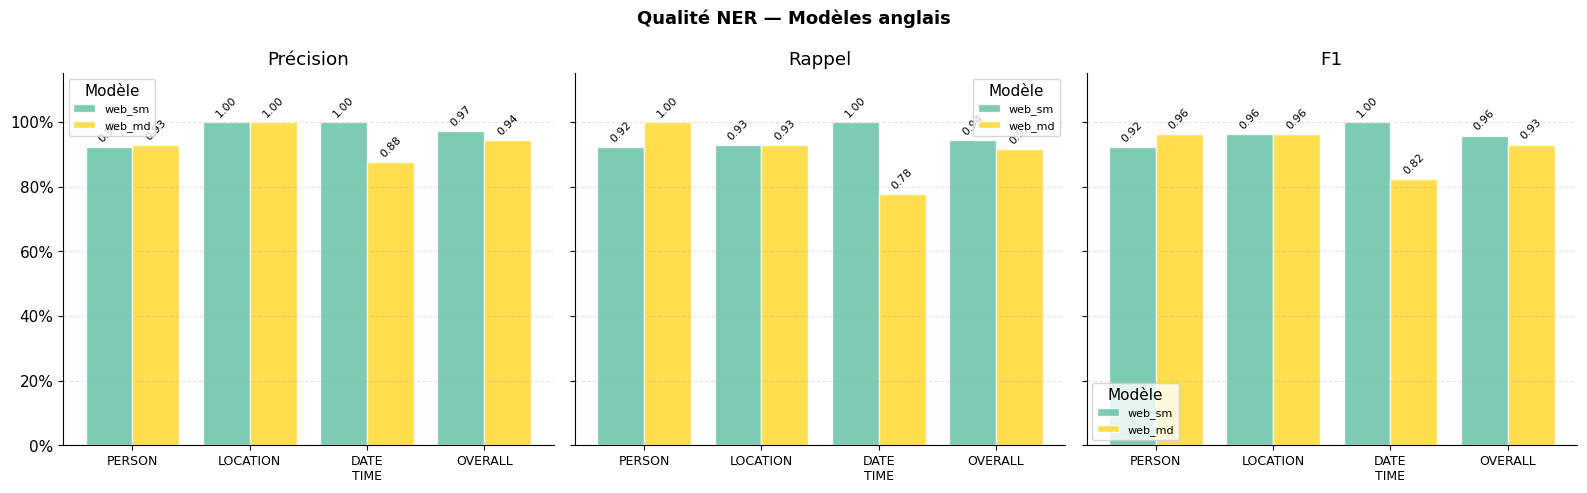


────────────────────────────────────────────────────────────
 Qualité — Français
────────────────────────────────────────────────────────────
               f1 precision  recall
model     news_sm   news_sm news_sm
entity                             
DATE_TIME   0.000     0.000    0.00
LOCATION    0.917     0.846    1.00
OVERALL     0.756     0.850    0.68
PERSON      0.800     0.857    0.75


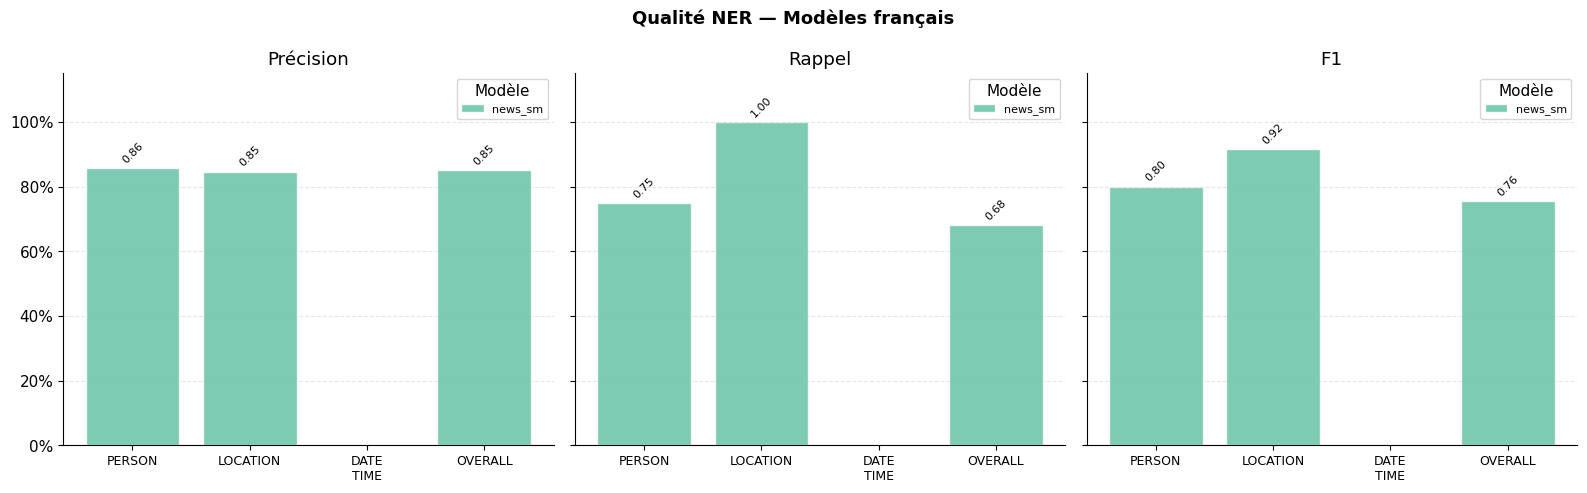

In [13]:
def build_quality_df(results: List[BenchmarkResult]) -> pd.DataFrame:
    rows = []
    for r in results:
        for entity, m in r.quality.items():
            rows.append({
                "model": r.model_name.split("_", 2)[-1],  # sm / md / lg / trf
                "model_full": r.model_name,
                "entity": entity,
                "precision": m.precision,
                "recall": m.recall,
                "f1": m.f1,
                "tp": m.tp, "fp": m.fp, "fn": m.fn,
            })
        # Ligne globale
        overall_tp = sum(m.tp for m in r.quality.values())
        overall_fp = sum(m.fp for m in r.quality.values())
        overall_fn = sum(m.fn for m in r.quality.values())
        om = EntityMatch(overall_tp, overall_fp, overall_fn)
        rows.append({
            "model": r.model_name.split("_", 2)[-1],
            "model_full": r.model_name,
            "entity": "OVERALL",
            "precision": om.precision,
            "recall": om.recall,
            "f1": om.f1,
            "tp": om.tp, "fp": om.fp, "fn": om.fn,
        })
    return pd.DataFrame(rows)


def display_quality_table(df: pd.DataFrame, title: str):
    pivot = df.pivot_table(
        index="entity", columns="model",
        values=["precision", "recall", "f1"],
        aggfunc="first",
    ).round(3)
    print(f"\n{'─' * 60}")
    print(f" {title}")
    print(f"{'─' * 60}")
    print(pivot.to_string())


def plot_quality(results: List[BenchmarkResult], title: str):
    if not results:
        print("Aucun résultat à afficher")
        return

    entities = NER_ENTITIES + ["OVERALL"]
    models = [r.model_name.split("_", 2)[-1] for r in results]
    x = np.arange(len(entities))
    width = 0.8 / len(models)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
    fig.suptitle(title, fontsize=13, fontweight="bold")

    metrics = [("precision", "Précision", "#4e79a7"),
               ("recall",    "Rappel",    "#f28e2b"),
               ("f1",        "F1",        "#59a14f")]

    colors = plt.cm.Set2(np.linspace(0, 0.7, len(models)))

    for ax, (metric, metric_label, _) in zip(axes, metrics):
        for i, (r, color) in enumerate(zip(results, colors)):
            values = []
            for entity in entities:
                if entity == "OVERALL":
                    total_tp = sum(m.tp for m in r.quality.values())
                    total_fp = sum(m.fp for m in r.quality.values())
                    total_fn = sum(m.fn for m in r.quality.values())
                    m = EntityMatch(total_tp, total_fp, total_fn)
                else:
                    m = r.quality.get(entity, EntityMatch())
                values.append(getattr(m, metric))

            offset = (i - len(models) / 2 + 0.5) * width
            bars = ax.bar(
                x + offset, values, width,
                label=r.model_name.split("_", 2)[-1],
                color=color, alpha=0.85, edgecolor="white",
            )
            for bar, val in zip(bars, values):
                if val > 0:
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.01,
                        f"{val:.2f}",
                        ha="center", va="bottom", fontsize=8, rotation=45,
                    )

        ax.set_title(metric_label)
        ax.set_xticks(x)
        ax.set_xticklabels([e.replace("_", "\n") for e in entities], fontsize=9)
        ax.set_ylim(0, 1.15)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
        ax.legend(title="Modèle", fontsize=8)
        ax.grid(axis="y", alpha=0.3, linestyle="--")

    plt.tight_layout()
    plt.show()


# ── Affichage ──
if en_results:
    df_en = build_quality_df(en_results)
    display_quality_table(df_en, "Qualité — Anglais")
    plot_quality(en_results, "Qualité NER — Modèles anglais")

if fr_results:
    df_fr = build_quality_df(fr_results)
    display_quality_table(df_fr, "Qualité — Français")
    plot_quality(fr_results, "Qualité NER — Modèles français")

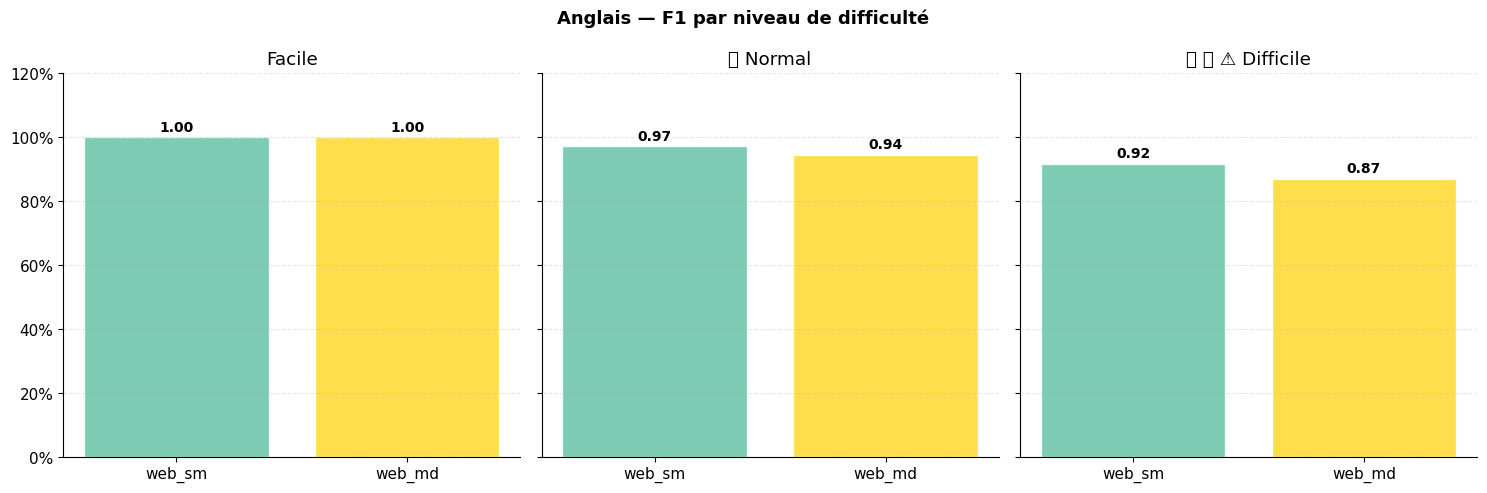

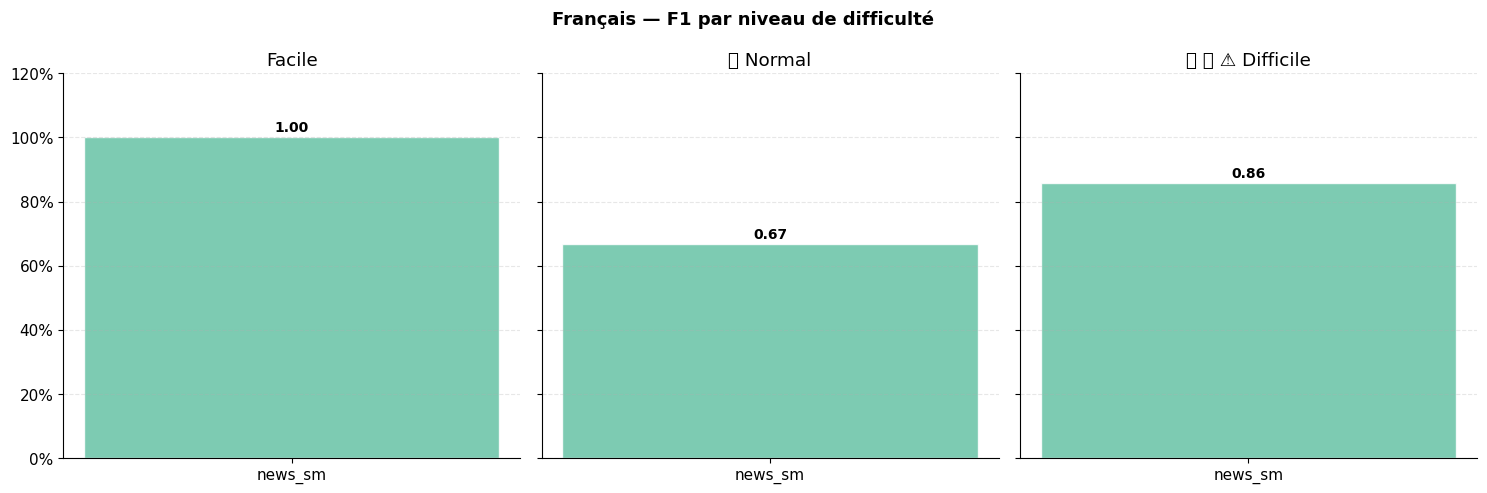

In [14]:
# ── Qualité par difficulté ──

def plot_quality_by_difficulty(results: List[BenchmarkResult], title: str):
    if not results:
        return

    difficulties = ["easy", "normal", "hard"]
    fig, axes = plt.subplots(1, len(difficulties), figsize=(15, 5), sharey=True)
    fig.suptitle(f"{title} — F1 par niveau de difficulté", fontsize=13, fontweight="bold")
    colors = plt.cm.Set2(np.linspace(0, 0.7, len(results)))

    for ax, diff in zip(axes, difficulties):
        models_short = [r.model_name.split("_", 2)[-1] for r in results]
        f1_scores = []
        for r in results:
            quality_diff = r.quality_by_difficulty.get(diff, {})
            if quality_diff:
                total_tp = sum(m.tp for m in quality_diff.values())
                total_fp = sum(m.fp for m in quality_diff.values())
                total_fn = sum(m.fn for m in quality_diff.values())
                f1_scores.append(EntityMatch(total_tp, total_fp, total_fn).f1)
            else:
                f1_scores.append(0.0)

        bars = ax.bar(models_short, f1_scores, color=colors[:len(results)], alpha=0.85, edgecolor="white")
        for bar, val in zip(bars, f1_scores):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f"{val:.2f}",
                ha="center", va="bottom", fontsize=10, fontweight="bold",
            )
        ax.set_title(f"{'⭐ ' * difficulties.index(diff) if diff != 'easy' else ''}{'Facile' if diff == 'easy' else 'Normal' if diff == 'normal' else '⚠️ Difficile'}")
        ax.set_ylim(0, 1.2)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
        ax.grid(axis="y", alpha=0.3, linestyle="--")

    plt.tight_layout()
    plt.show()


if en_results:
    plot_quality_by_difficulty(en_results, "Anglais")

if fr_results:
    plot_quality_by_difficulty(fr_results, "Français")

---
## 7. Analyse vitesse : latence & débit <a id="7-speed"></a>

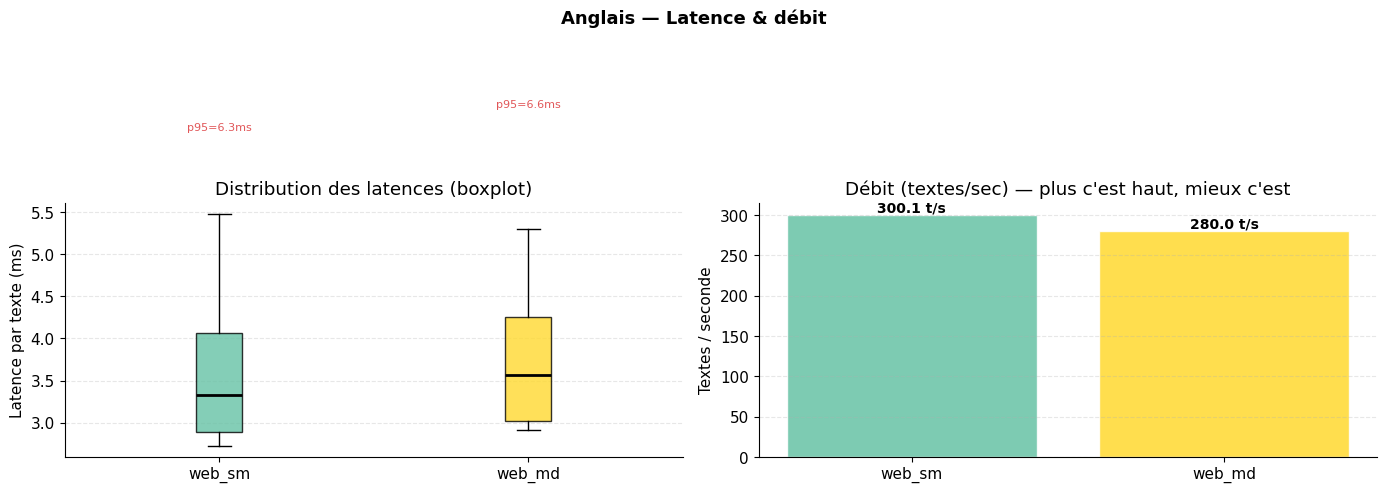


Tableau latence :
        modèle p50 (ms) p95 (ms) débit (t/s)
en_core_web_sm     3.33     6.34       300.1
en_core_web_md     3.57     6.62       280.0


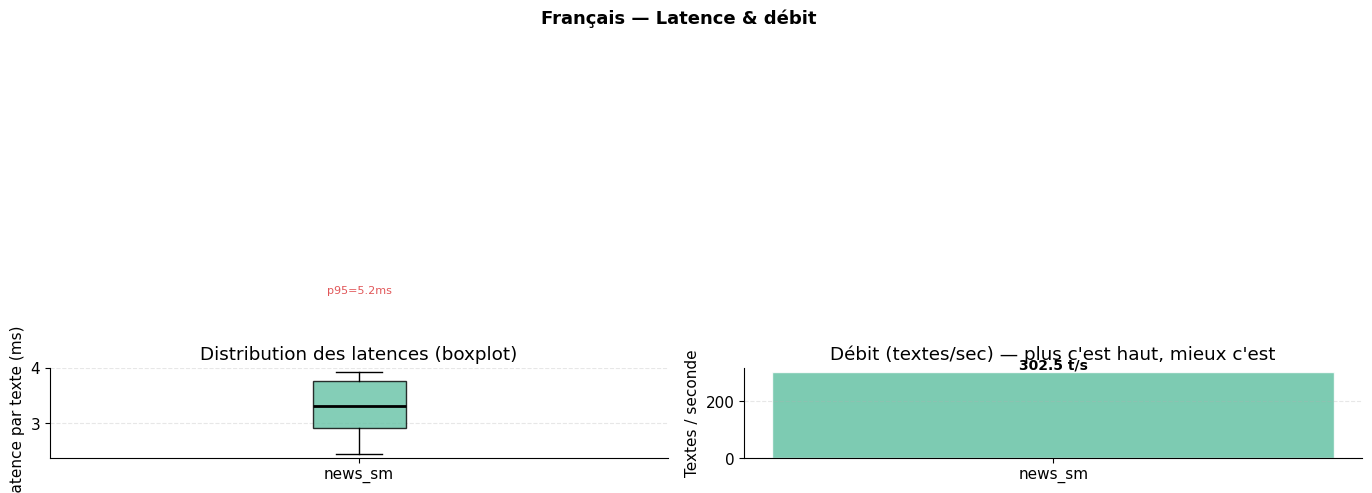


Tableau latence :
         modèle p50 (ms) p95 (ms) débit (t/s)
fr_core_news_sm     3.31     5.21       302.5


In [15]:
def plot_latency(results: List[BenchmarkResult], title: str):
    if not results:
        return

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{title} — Latence & débit", fontsize=13, fontweight="bold")

    models_short = [r.model_name.split("_", 2)[-1] for r in results]
    colors = plt.cm.Set2(np.linspace(0, 0.7, len(results)))

    # ── Boxplot des temps par texte ──
    ax = axes[0]
    data_ms = [[t * 1000 for t in r.times_per_text] for r in results]
    bp = ax.boxplot(
        data_ms,
        labels=models_short,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="black", linewidth=2),
    )
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    ax.set_ylabel("Latence par texte (ms)")
    ax.set_title("Distribution des latences (boxplot)")
    ax.grid(axis="y", alpha=0.3, linestyle="--")

    # Annotations p50 / p95
    for i, r in enumerate(results):
        ax.text(
            i + 1, np.percentile(r.times_per_text, 95) * 1000 + 0.1,
            f"p95={r.p95_latency_ms:.1f}ms",
            ha="center", va="bottom", fontsize=8, color="#e15759",
        )

    # ── Débit (textes/sec) ──
    ax2 = axes[1]
    throughputs = [r.throughput_tps for r in results]
    bars = ax2.bar(models_short, throughputs, color=colors[:len(results)], alpha=0.85, edgecolor="white")
    for bar, val in zip(bars, throughputs):
        ax2.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{val:.1f} t/s",
            ha="center", va="bottom", fontsize=10, fontweight="bold",
        )
    ax2.set_ylabel("Textes / seconde")
    ax2.set_title("Débit (textes/sec) — plus c'est haut, mieux c'est")
    ax2.grid(axis="y", alpha=0.3, linestyle="--")

    plt.tight_layout()
    plt.show()

    # Tableau récapitulatif
    print("\nTableau latence :")
    df_lat = pd.DataFrame([
        {
            "modèle": r.model_name,
            "p50 (ms)": f"{r.median_latency_ms:.2f}",
            "p95 (ms)": f"{r.p95_latency_ms:.2f}",
            "débit (t/s)": f"{r.throughput_tps:.1f}",
        }
        for r in results
    ])
    print(df_lat.to_string(index=False))


if en_results:
    plot_latency(en_results, "Anglais")

if fr_results:
    plot_latency(fr_results, "Français")

---
## 8. Analyse mémoire <a id="8-memory"></a>

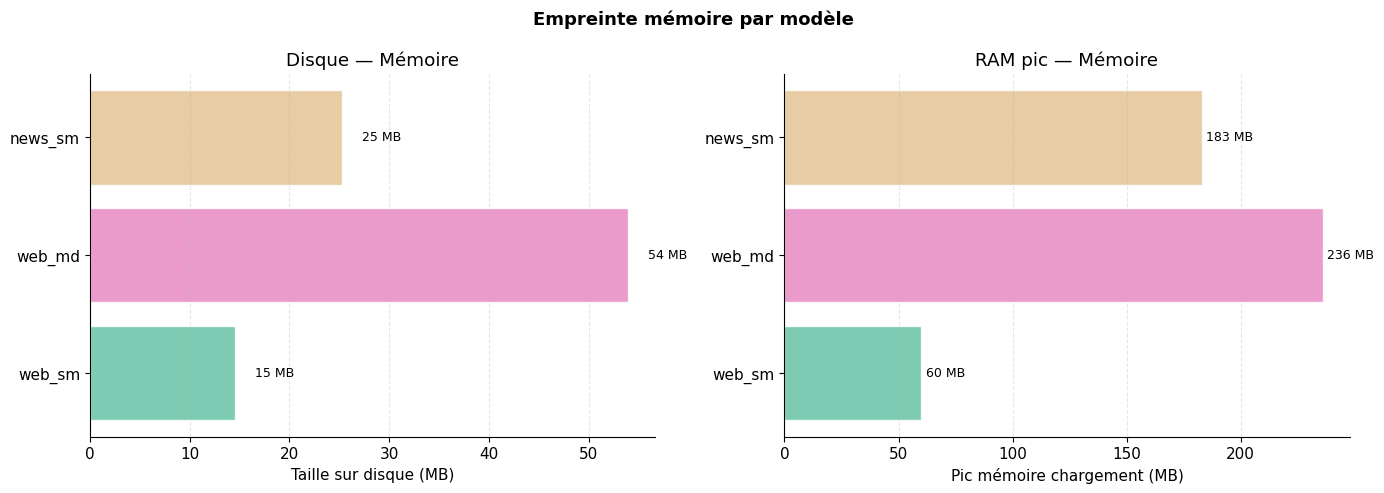


Tableau mémoire :
         modèle langue disque (MB) pic RAM (MB)
 en_core_web_sm     en          15           60
 en_core_web_md     en          54          236
fr_core_news_sm     fr          25          183


In [16]:
def plot_memory(all_results: List[BenchmarkResult], title: str = "Mémoire"):
    if not all_results:
        return

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Empreinte mémoire par modèle", fontsize=13, fontweight="bold")
    colors = plt.cm.Set2(np.linspace(0, 0.8, len(all_results)))

    models = [r.model_name for r in all_results]
    sizes_mb = [r.model_size_mb for r in all_results]
    peak_mb  = [r.peak_memory_mb for r in all_results]

    for ax, values, ylabel, col_prefix in [
        (axes[0], sizes_mb, "Taille sur disque (MB)", "Disque"),
        (axes[1], peak_mb,  "Pic mémoire chargement (MB)", "RAM pic"),
    ]:
        bars = ax.barh(
            [m.split("_", 2)[-1] for m in models],
            values, color=colors[:len(all_results)], alpha=0.85, edgecolor="white",
        )
        for bar, val in zip(bars, values):
            ax.text(
                bar.get_width() + 2,
                bar.get_y() + bar.get_height() / 2,
                f"{val:.0f} MB",
                ha="left", va="center", fontsize=9,
            )
        ax.set_xlabel(ylabel)
        ax.set_title(f"{col_prefix} — {title}")
        ax.grid(axis="x", alpha=0.3, linestyle="--")

    plt.tight_layout()
    plt.show()


all_results = en_results + fr_results
if all_results:
    plot_memory(all_results)

    print("\nTableau mémoire :")
    df_mem = pd.DataFrame([
        {
            "modèle": r.model_name,
            "langue": r.language,
            "disque (MB)": f"{r.model_size_mb:.0f}",
            "pic RAM (MB)": f"{r.peak_memory_mb:.0f}",
        }
        for r in all_results
    ])
    print(df_mem.to_string(index=False))

---
## 9. Synthèse & recommandations <a id="9-summary"></a>

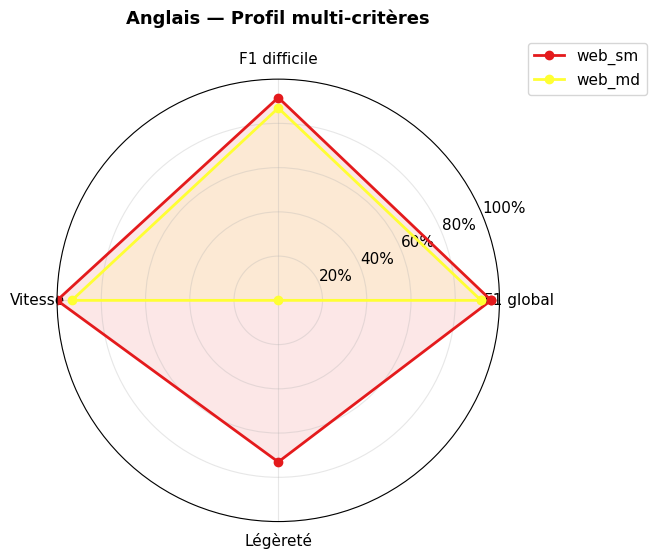

In [17]:
# ── Radar chart F1 / vitesse / légèreté ──

def plot_radar(results: List[BenchmarkResult], title: str):
    if len(results) < 2:
        print(f"Radar nécessite ≥2 modèles (actuel: {len(results)})")
        return

    categories = ["F1 global", "F1 difficile", "Vitesse", "Légèreté"]
    N = len(categories)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # fermer le polygone

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    ax.set_title(f"{title} — Profil multi-critères", pad=20, fontsize=13, fontweight="bold")

    colors = plt.cm.Set1(np.linspace(0, 0.6, len(results)))

    # Normalisation des métriques pour ramener tout entre 0 et 1
    max_tps   = max(r.throughput_tps  for r in results) or 1
    max_size  = max(r.model_size_mb   for r in results) or 1

    for r, color in zip(results, colors):
        # F1 difficile
        hard_q = r.quality_by_difficulty.get("hard", {})
        hard_tp = sum(m.tp for m in hard_q.values())
        hard_fp = sum(m.fp for m in hard_q.values())
        hard_fn = sum(m.fn for m in hard_q.values())
        hard_f1 = EntityMatch(hard_tp, hard_fp, hard_fn).f1

        values = [
            r.overall_f1,                          # F1 global
            hard_f1,                               # F1 difficile
            r.throughput_tps / max_tps,            # Vitesse normalisée
            1 - r.model_size_mb / max_size,        # Légèreté (inverse de la taille)
        ]
        values += values[:1]

        short_name = r.model_name.split("_", 2)[-1]
        ax.plot(angles, values, "o-", color=color, linewidth=2, label=short_name)
        ax.fill(angles, values, color=color, alpha=0.1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=11)
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1))
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


if len(en_results) >= 2:
    plot_radar(en_results, "Anglais")
if len(fr_results) >= 2:
    plot_radar(fr_results, "Français")

In [18]:
# ── Tableau de synthèse final ──

def print_final_summary(results: List[BenchmarkResult], lang: str):
    if not results:
        return
    print(f"\n{'═' * 75}")
    print(f" Synthèse — {lang}")
    print(f"{'═' * 75}")
    print(f"  {'Modèle':<22} {'F1':>6} {'Précision':>10} {'Rappel':>8} {'p50(ms)':>9} {'Débit':>8} {'Taille':>8}")
    print(f"  {'─' * 73}")

    best_f1 = max(r.overall_f1 for r in results)
    best_tps = max(r.throughput_tps for r in results)

    for r in sorted(results, key=lambda x: x.overall_f1, reverse=True):
        total_tp = sum(m.tp for m in r.quality.values())
        total_fp = sum(m.fp for m in r.quality.values())
        total_fn = sum(m.fn for m in r.quality.values())
        om = EntityMatch(total_tp, total_fp, total_fn)

        flag_f1  = " 🏆" if r.overall_f1 == best_f1 else ""
        flag_tps = " ⚡" if r.throughput_tps == best_tps else ""

        print(
            f"  {r.model_name:<22} "
            f"{om.f1:>6.2f}{flag_f1:<4} "
            f"{om.precision:>8.2f}   "
            f"{om.recall:>6.2f}   "
            f"{r.median_latency_ms:>7.1f}ms "
            f"{r.throughput_tps:>5.1f}t/s{flag_tps:<3} "
            f"{r.model_size_mb:>6.0f}MB"
        )


print_final_summary(en_results, "Anglais")
print_final_summary(fr_results, "Français")


═══════════════════════════════════════════════════════════════════════════
 Synthèse — Anglais
═══════════════════════════════════════════════════════════════════════════
  Modèle                     F1  Précision   Rappel   p50(ms)    Débit   Taille
  ─────────────────────────────────────────────────────────────────────────
  en_core_web_sm           0.96 🏆       0.97     0.94       3.3ms 300.1t/s ⚡      15MB
  en_core_web_md           0.93         0.94     0.92       3.6ms 280.0t/s        54MB

═══════════════════════════════════════════════════════════════════════════
 Synthèse — Français
═══════════════════════════════════════════════════════════════════════════
  Modèle                     F1  Précision   Rappel   p50(ms)    Débit   Taille
  ─────────────────────────────────────────────────────────────────────────
  fr_core_news_sm          0.76 🏆       0.85     0.68       3.3ms 302.5t/s ⚡      25MB


In [19]:
# ── Recommandations pour RAGFlow ──

print()
print("╔" + "═" * 65 + "╗")
print("║  Recommandations pour RAGFlow (PII_MASKING_NER_MODEL_*)       ║")
print("╠" + "═" * 65 + "╣")
print("║                                                               ║")
print("║  Production (qualité prioritaire)                             ║")
print("║    EN : PII_MASKING_NER_MODEL_EN=en_core_web_lg               ║")
print("║    FR : PII_MASKING_NER_MODEL_FR=fr_core_news_lg              ║")
print("║                                                               ║")
print("║  Ressources limitées / développement (valeur par défaut)      ║")
print("║    EN : PII_MASKING_NER_MODEL_EN=en_core_web_sm  (~12 MB)     ║")
print("║    FR : PII_MASKING_NER_MODEL_FR=fr_core_news_sm (~15 MB)     ║")
print("║                                                               ║")
print("║  Meilleure qualité possible (GPU disponible)                  ║")
print("║    EN : PII_MASKING_NER_MODEL_EN=en_core_web_trf (~440 MB)    ║")
print("║         → nécessite spacy[transformers]                       ║")
print("║                                                               ║")
print("║  Note : sans NER (PII_MASKING_NER=false), seules les entités  ║")
print("║  détectables par regex sont couvertes : EMAIL, PHONE,         ║")
print("║  CREDIT_CARD, IBAN, IP_ADDRESS — pas PERSON ni LOCATION.      ║")
print("╚" + "═" * 65 + "╝")

# Mise en évidence des résultats réels du benchmark
if en_results:
    best = max(en_results, key=lambda r: r.overall_f1)
    fastest = max(en_results, key=lambda r: r.throughput_tps)
    print(f"\n  D'après ce benchmark EN :")
    print(f"    Meilleur F1    → {best.model_name} (F1={best.overall_f1:.2f})")
    print(f"    Plus rapide    → {fastest.model_name} ({fastest.throughput_tps:.1f} t/s)")

if fr_results:
    best = max(fr_results, key=lambda r: r.overall_f1)
    fastest = max(fr_results, key=lambda r: r.throughput_tps)
    print(f"\n  D'après ce benchmark FR :")
    print(f"    Meilleur F1    → {best.model_name} (F1={best.overall_f1:.2f})")
    print(f"    Plus rapide    → {fastest.model_name} ({fastest.throughput_tps:.1f} t/s)")


╔═════════════════════════════════════════════════════════════════╗
║  Recommandations pour RAGFlow (PII_MASKING_NER_MODEL_*)       ║
╠═════════════════════════════════════════════════════════════════╣
║                                                               ║
║  Production (qualité prioritaire)                             ║
║    EN : PII_MASKING_NER_MODEL_EN=en_core_web_lg               ║
║    FR : PII_MASKING_NER_MODEL_FR=fr_core_news_lg              ║
║                                                               ║
║  Ressources limitées / développement (valeur par défaut)      ║
║    EN : PII_MASKING_NER_MODEL_EN=en_core_web_sm  (~12 MB)     ║
║    FR : PII_MASKING_NER_MODEL_FR=fr_core_news_sm (~15 MB)     ║
║                                                               ║
║  Meilleure qualité possible (GPU disponible)                  ║
║    EN : PII_MASKING_NER_MODEL_EN=en_core_web_trf (~440 MB)    ║
║         → nécessite spacy[transformers]                       ║
║    